In [1]:
import time 
import numpy as np
from matplotlib import pyplot as plt
from redpitaya_io_sync.device.rp_125_14_z7010 import Rp_125_14_Z7010
from redpitaya_io_sync.sequence import IoSequence
from redpitaya_io_sync.frame import IoSyncFrame, ParametrizedIoSyncFrame
from redpitaya_io_sync.io.scope import ScopeSource

### Device instances

In [2]:
rp_0 = Rp_125_14_Z7010(ip="192.168.1.143", label="rp_0")

### IO Sequences & IO Frames instances

In [3]:
seq = IoSequence(device_list=[rp_0])
fr_0 = ParametrizedIoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_1 = ParametrizedIoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_2 = ParametrizedIoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_3 = ParametrizedIoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)

### Parameters

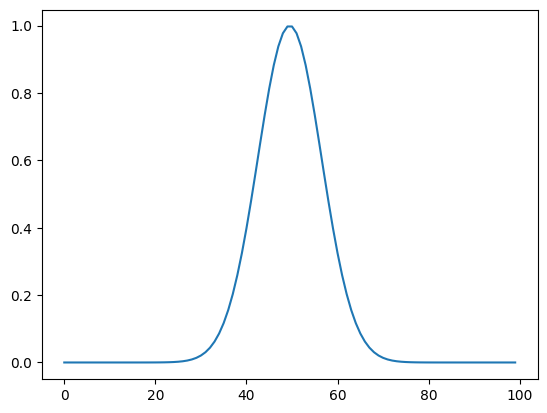

In [4]:

param_dict = {
    "rf_init" : {
        "frequency" : 0,
        "phase" : 0,
        "amplitude" : 0
        },
    "led" : {
        "led_on_idx" : 0
    },
    "rf_in_out" :{
        "samples": 100,
        "acq_delay": 0
    },
    "wait" : {
        "duration": 1000
    }
}

data_out_list = np.exp(-np.linspace(-5, 5, 100)**2) 

plt.plot(data_out_list)
plt.show()


### Frame definitions 


In [5]:

def rf_init(fr : IoSyncFrame, fr_param: dict):
    print("--> Building RF init frame")
    fr.reset()
    fr.led.output(val=0, mask = 0xff)
    fr.rf_out_1.frequency(fr_param["frequency"])
    fr.rf_out_1.phase(fr_param["phase"])
    fr.rf_out_1.amplitude(fr_param["amplitude"])
    fr.rf_out_1.phase_reset()
    fr.delay(1000)

def led_update(fr: IoSyncFrame, fr_param: dict):
    print("--> Building LED update frame")
    fr.reset()
    fr.led.output(val=(1 << fr_param["led_on_idx"]), mask=(1 << fr_param["led_on_idx"]))
    
def rf_in_out(fr: IoSyncFrame, fr_param: dict):
    print("--> Building RF in/out frame")
    fr.reset()
    fr.scope_1.source(ScopeSource.RF_IN_1)
    fr.scope_1.decimation(1) 
    fr.rsync()
    for data_out in data_out_list:
        fr.rf_out_1.amplitude(data_out)
    fr.scope_1.delay(fr_param["acq_delay"])
    fr.scope_1.acquire(samples=fr_param["samples"], label="acq_rf")

def wait(fr: IoSyncFrame, fr_param: dict):
    print("--> Building wait frame")
    fr.reset()
    fr.delay(fr_param["duration"]) 


In [6]:
fr_0.set_frame_function(rf_init)
fr_0.set_frame_parameter(param_dict["rf_init"])
fr_1.set_frame_function(led_update)
fr_1.set_frame_parameter(param_dict["led"])
fr_2.set_frame_function(rf_in_out)
fr_2.set_frame_parameter(param_dict["rf_in_out"])
fr_3.set_frame_function(wait)
fr_3.set_frame_parameter(param_dict["wait"])

### Sequence definition

In [7]:
seq.reset()
seq.add_frame(frame=fr_0, device=rp_0, label="rf init")
seq.add_frame(frame=fr_1, device=rp_0, label="led update")
seq.add_frame(frame=fr_2, device=rp_0, label="rf in out")
seq.add_frame(frame=fr_3, device=rp_0, label="wait")

print(seq.sequence_description())

+--------------------+
| rp_0@192.168.1.143 |
+--------------------+
| rf init            |
| led update         |
| rf in out          |
| wait               |
+--------------------+
NOTE: Frames with (*) are triggered by external trigger source.



### Run scan

In [8]:
N=32
delay_list = np.arange(N) #generate a list of delays from 0 to N-1
led_val_list = np.linspace(0, 7, N, dtype=int) #progressively turn on more LEDs
overlap_list = [] #overlap between RF out and scope acquisition


for i in range(N):
    print(f"Iteration {i}: led_on_idx={led_val_list[i]}, acq_delay={delay_list[i]}")
    
    param_dict["led"]["led_on_idx"] = led_val_list[i]
    param_dict["rf_in_out"]["acq_delay"] = delay_list[i]
    
    seq.upload(force=False)
    seq.start()
    seq.wait()
    
    scope_dict = seq.get_scope()
    data_in_list = scope_dict[rp_0.get_uid()]["rf in out"]["scope_1"]["acq_rf"]["data"]
    norm_in = np.sqrt(np.sum(data_in_list.astype(float)**2))
    norm_out = np.sqrt(np.sum(data_out_list.astype(float)**2))
    overlap = np.sum(data_in_list.astype(float)*data_out_list.astype(float)) / (norm_in*norm_out)
    overlap_list.append(overlap)


Iteration 0: led_on_idx=0, acq_delay=0
--> Building RF init frame
--> Building LED update frame
--> Building RF in/out frame
--> Building wait frame
Iteration 1: led_on_idx=0, acq_delay=1
--> Building RF in/out frame
Iteration 2: led_on_idx=0, acq_delay=2
--> Building RF in/out frame
Iteration 3: led_on_idx=0, acq_delay=3
--> Building RF in/out frame
Iteration 4: led_on_idx=0, acq_delay=4
--> Building RF in/out frame
Iteration 5: led_on_idx=1, acq_delay=5
--> Building LED update frame
--> Building RF in/out frame
Iteration 6: led_on_idx=1, acq_delay=6
--> Building RF in/out frame
Iteration 7: led_on_idx=1, acq_delay=7
--> Building RF in/out frame
Iteration 8: led_on_idx=1, acq_delay=8
--> Building RF in/out frame
Iteration 9: led_on_idx=2, acq_delay=9
--> Building LED update frame
--> Building RF in/out frame
Iteration 10: led_on_idx=2, acq_delay=10
--> Building RF in/out frame
Iteration 11: led_on_idx=2, acq_delay=11
--> Building RF in/out frame
Iteration 12: led_on_idx=2, acq_delay=1

In [9]:
seq.stop()

### Plot acquisitions


RF loopback latency: 14 clk cycles


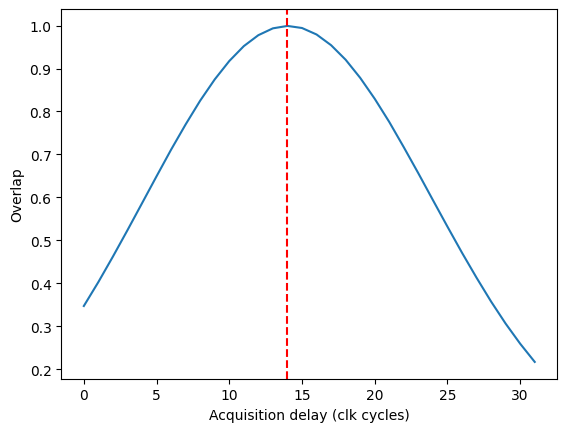

In [12]:
rf_out_in_latency = delay_list[np.argmax(overlap_list)]
print(f"RF loopback latency: {rf_out_in_latency} clk cycles")
plt.plot(delay_list, overlap_list)
plt.xlabel("Acquisition delay (clk cycles)")
plt.ylabel("Overlap")
plt.axvline(rf_out_in_latency, color='r', linestyle='--')
plt.show()